# Tasic et al. (2018) – Shared and distinct transcriptomic cell types across neocortical areas  
The original paper can be found here: https://www.nature.com/articles/s41586-018-0654-5

__Abstract__: The neocortex contains a rich variety of neuronal and non-neuronal cell types, organized into layers and specialized areas. Tasic et al. profile ~23k individual cells from adult mouse primary visual cortex (VISp) and anterior lateral motor cortex (ALM) using deep single-cell RNA-seq, and define 133 transcriptomic cell types. Inhibitory (GABAergic) neuron types are largely shared between the two regions, whereas most glutamatergic excitatory neuron types are specific to either VISp or ALM. By combining scRNA-seq with retrograde labelling of long-range projections, they link transcriptomic excitatory types to their projection targets and establish a joint transcriptomic and projectional taxonomy of neocortical cell types.

A mouse neocortical benchmark: full-length Smart-seq v4 scRNA-seq of adult C57BL/6J mouse cortex, covering neurons and glia from VISp and ALM. Cells were FACS-sorted from transgenic reporter lines and sequenced on an Illumina HiSeq 2500, yielding high-depth expression profiles (often tens of thousands of detected genes per cell). The dataset is widely used as a reference atlas for mouse cortical cell types and as a benchmark for clustering, annotation, and data-integration methods, since both broad classes (excitatory, inhibitory, non-neuronal) and fine-grained transcriptomic types are well curated.

From public resources (Allen Institute / GEO): The data are deposited under GEO series accession GSE115746 and are also available in processed form via the Allen Cell Types database. For benchmarking purposes, many studies work with a quality-filtered subset of ~20–25k cells, retaining well-annotated excitatory and inhibitory neurons (and sometimes selected non-neuronal classes) to create a reference dataset with known cell-type labels across layers and areas.  
Tasic, Bosiljka, et al. "Shared and distinct transcriptomic cell types across neocortical areas." *Nature* 563.7729 (2018): 72–78.


## 0. Imports & Set-Up:

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [2]:
import sys

sys.path.insert(0, "..")

import multiprocessing
import os, random

from pathlib import Path

from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import anndata as ad

from carve import CARVE

In [3]:
SUBSAMPLE = True
# subsample_size = 0.3
subsample_size = 0.1

In [4]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

In [5]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass

    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)


N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [6]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [7]:
from benchmarking_code.benchmarking_utils import gamma_quantile_approx
from benchmarking_code.case_study_plotting import (
    fragmentation_report,
    plot_dim_red,
    calculate_baseline_aris_and_plot,
    baseline_metrics_over_k,
    alluvial_compare,
    plot_label_split_counts,
    merging_report,
    plot_label_merge_counts,
)

---

## 1. Pre-Process the Data

In [8]:
tasic_dir = Path("../../data/TasicData/")

X_raw = pd.read_csv(tasic_dir / "tasic-post-PCA_23822x1000-final.csv")
labels = pd.read_csv(tasic_dir / "tasic-metadata-final.csv")

In [9]:
y_raw = labels["cluster_id"]
len(pd.Categorical(y_raw).categories)

133

In [10]:
X_raw.shape, y_raw.shape

((23822, 1000), (23822,))

We have determined that a t-SNE embedding with a perplexity of 22 minimizes reconstruction loss:

In [11]:
Z = TSNE(perplexity=22, random_state=RANDOM_SEED).fit_transform(X_raw)

In [12]:
print("Number of clusters:", labels["cluster_label"].nunique())
print("Class labels:", labels["class_label"].value_counts())

Number of clusters: 133
Class labels: class_label
Glutamatergic    11905
GABAergic        10534
Non-Neuronal      1047
Endothelial        336
Name: count, dtype: int64


---

## 2. Analyse Data

In [13]:
X = Z
y = y_raw

print(f"X shape (cells × genes): {X.shape[0]:,} × {X.shape[1]:,}")
print(f"y shape: {y_raw.shape}")
print(f"Number of unique cell types in y: {y_raw.nunique()}")

X shape (cells × genes): 23,822 × 2
y shape: (23822,)
Number of unique cell types in y: 133


In [14]:
# Stratified subsampling
if SUBSAMPLE:
    if isinstance(subsample_size, float):
        subsample_size = int(subsample_size * X.shape[0])
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)

    _, idx = next(sss.split(X, y_raw))
    selected_idx = y_raw.index[idx]

    X_sub = X[idx]
    y_sub = y_raw.loc[selected_idx]

    X = X_sub
    y = y_sub

    print("X shape:", X.shape)

X shape: (2382, 2)


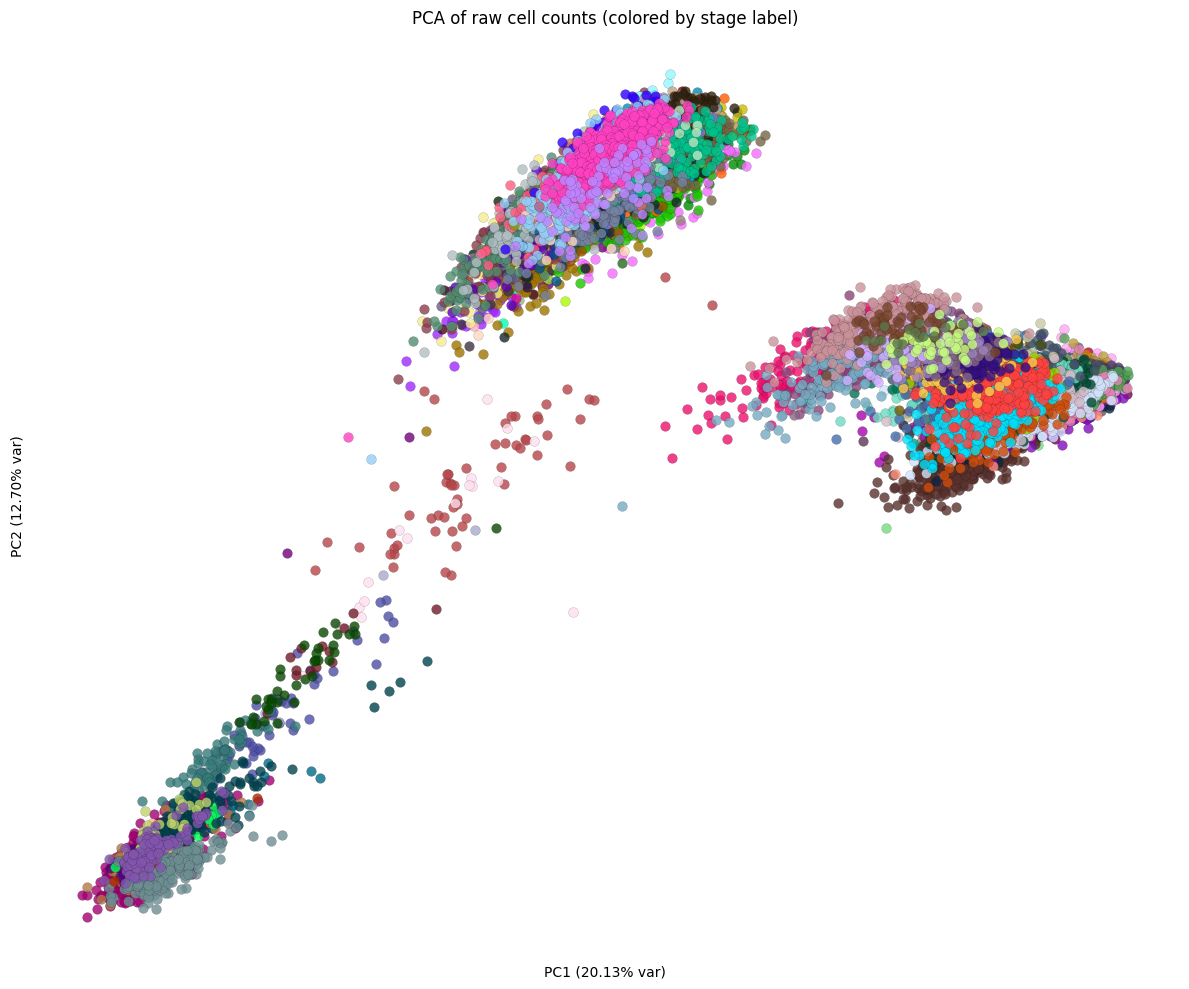

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'PCA of raw cell counts (colored by stage label)'}, xlabel='PC1 (20.13% var)', ylabel='PC2 (12.70% var)'>)

In [15]:
plot_dim_red(X=X_raw, y=y_raw, show_legend=False)

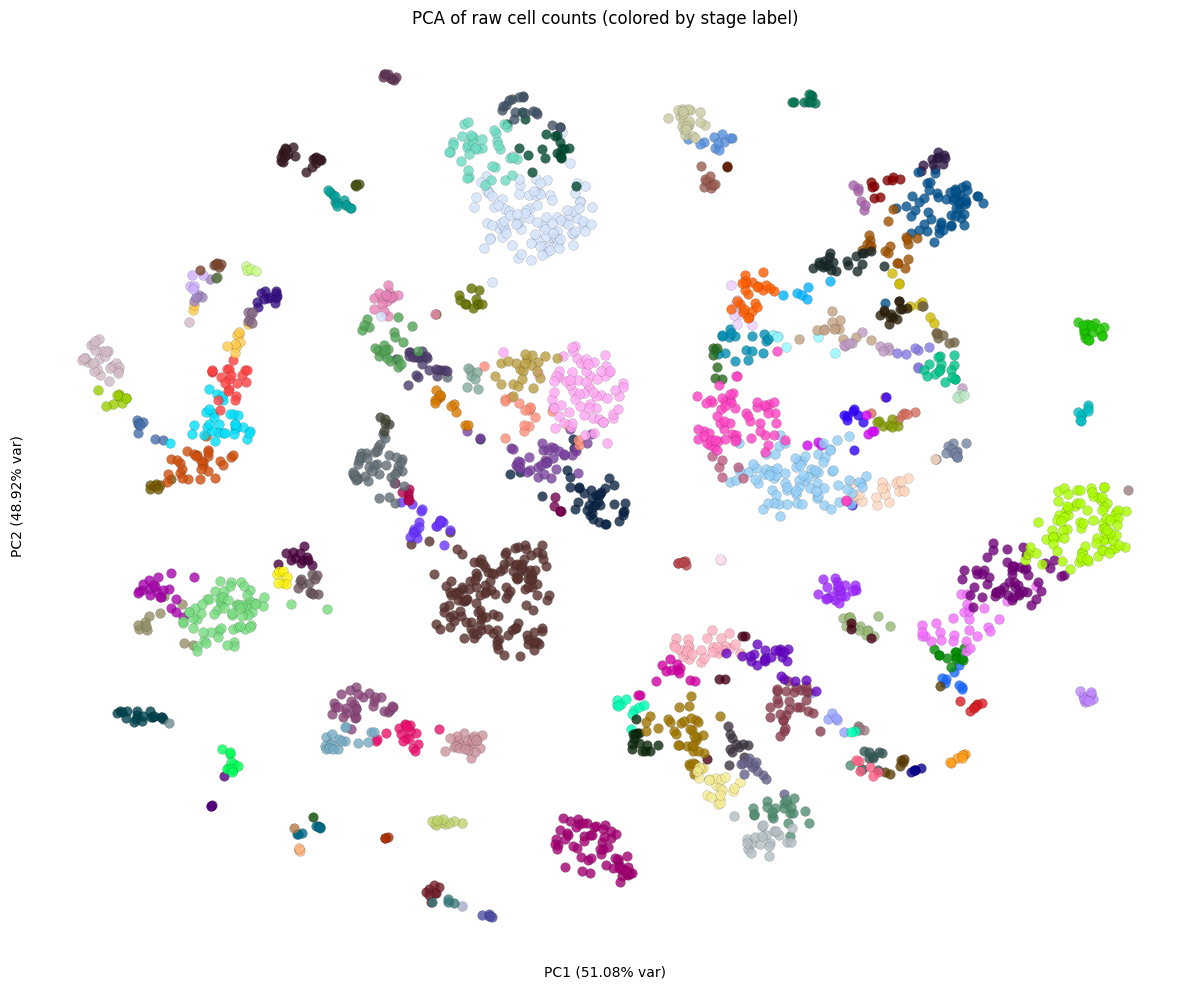

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: title={'center': 'PCA of raw cell counts (colored by stage label)'}, xlabel='PC1 (51.08% var)', ylabel='PC2 (48.92% var)'>)

In [16]:
plot_dim_red(X=X, y=y, show_legend=False)

### 2.2 Perform Clustering with "Oracle" Number of Clusters:

In [17]:
# calculate_baseline_aris_and_plot(X=X, y=y, random_state=RANDOM_SEED)

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

In [18]:
K = 40
ks = list(range(10, K + 1))

gamma = gamma_quantile_approx(X, q=0.50, random_state=RANDOM_SEED)

model_grids = [
    (KMeans, {"n_clusters": ks}),
    # (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward", "single", "complete", "average"]}),
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward", "single"]}),
]


baseline selections (max metric):
  - Silhouette: k=38, score=0.5085, ari=0.6400   [KMeans]
  - Gap Statistic: k=35, score=2.8963, ari=0.2835   [Agglomerative (linkage=single)]
  - DB: k=25, score=0.6473, ari=0.2515   [Agglomerative (linkage=single)]
  - CH: k=40, score=4187.6274, ari=0.6481   [KMeans]


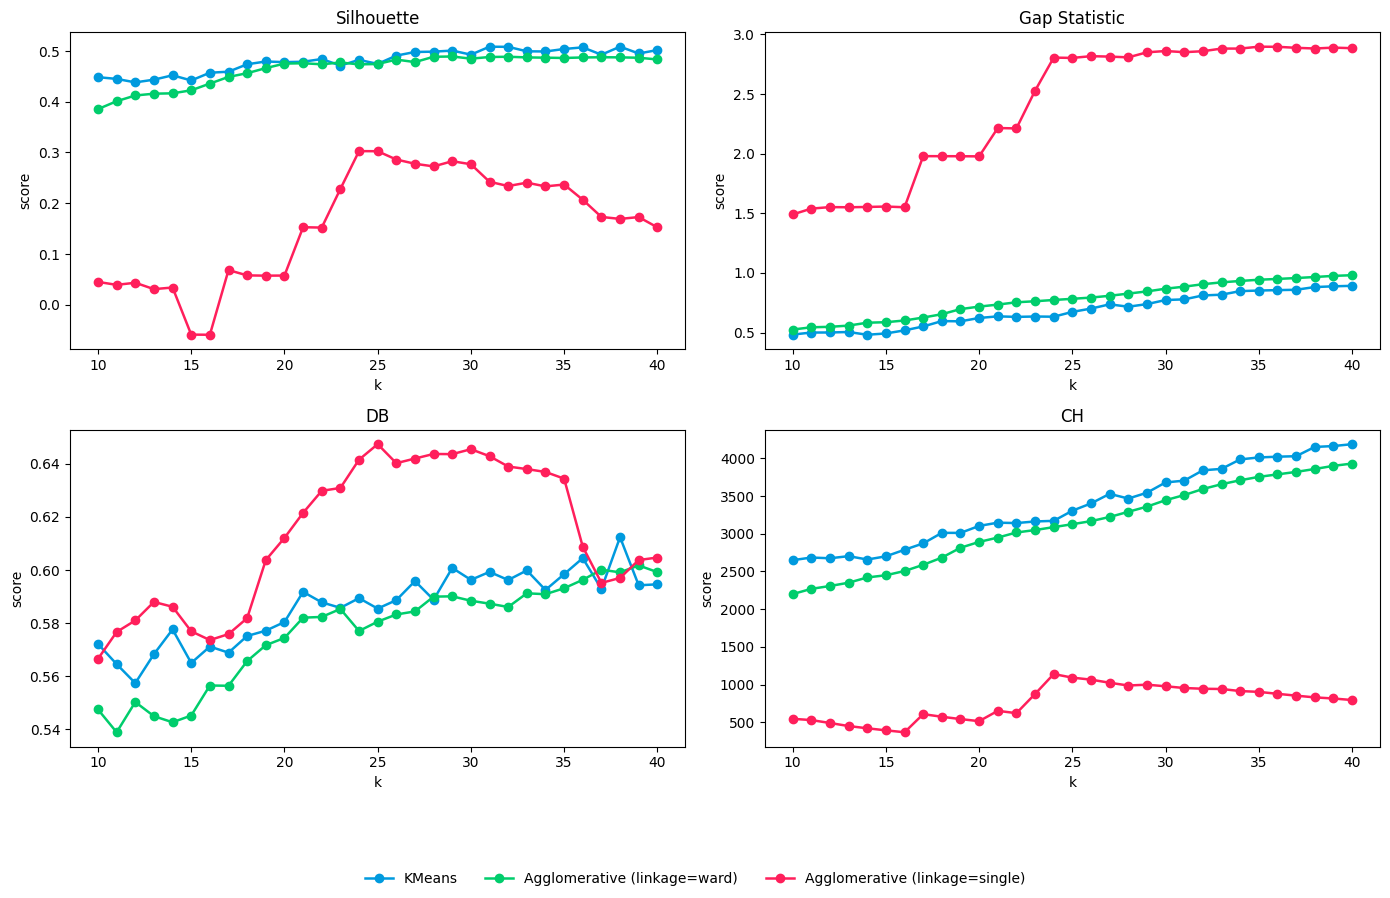

In [19]:
curves_df, best_df = baseline_metrics_over_k(
    X,
    y=y,
    model_grids=model_grids,
    metrics=["silhouette", "gap", "DB", "CH"],
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
    ncols=2,
    figsize=(14, 9),
)

---

## 4. Run CARVE:

In [20]:
carve = CARVE(
    estimator_param_grids=model_grids, n_jobs=N_JOBS, random_state=RANDOM_SEED
)

carve.fit(X, reference_labels=y)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 2382
[CARVE] n_features         : 2
[CARVE] n_clusters         : 10
[CARVE] n_resamples        : 100
[CARVE] subsample_ratio    : 0.8
[CARVE] n_jobs             : 10
[CARVE] total configs      : 93
[CARVE] random_preprocess  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/93] est=KMeans n_clusters=10 | ARI_stab=0.771±0.011  ARI_gen=0.514±0.009  ARI_avg=0.642±0.008
[CARVE] [2/93] est=KMeans n_clusters=11 | ARI_stab=0.767±0.009  ARI_gen=0.536±0.008  ARI_avg=0.651±0.006
[CARVE] [3/93] est=KMeans n_clusters=12 | ARI_stab=0.759±0.009  ARI_gen=0.543±0.008  ARI_avg=0.651±0.007
[CARVE] [4/93] est=KMeans n_clusters=13 | ARI_stab=0.739±0.008  ARI_gen=0.527±0.009  ARI_avg=0.633±0.006
[CARVE] [5/93] est=KMeans n_clusters=14 | ARI_stab=0.728±0.006  ARI_gen=0.521±0.007  

,n_clusters,10
,n_resamples,100
,subsample_ratio,0.8
,estimator_param_grids,"[(<class 'sklea...means.KMeans'>, ...), (<class 'sklea...veClustering'>, ...)]"
,normalization_options,None
,dim_reduction_options,None
,reference_labels,"array([ 57, 1...98, 31, 107])"
,n_jobs,10
,random_state,42
,verbose,1


In [21]:
# carve.plot_metric_over_k(measure='g', rule='1se')

In [22]:
# carve.plot_metric_over_k(measure='s', rule='quantile')

In [23]:
# carve.plot_consensus_matrix(k=27)

Plotting as suggested by CARVE:

In [24]:
# carve.plot_cluster_summary(measure='g', rule='1se')

In [25]:
# carve.plot_cluster_summary(measure='s', rule='quantile')

### 4.1 Composite Paper Figure

In [26]:
# Build the silhouette-selected labels (best model from baseline sweep)
from itertools import product as _product
from benchmarking_code.benchmarking_utils import _build_estimator
from benchmarking_code.case_study_plotting import _pretty_model_label

sil_best = best_df[best_df["metric"] == "silhouette"].iloc[0]
sil_model_name = sil_best["best_model"]
sil_k = int(sil_best["best_k"])

for est_cls, grid in model_grids:
    other_keys = [k for k in grid.keys() if k != "n_clusters"]
    other_vals = [
        grid[k] if isinstance(grid[k], (list, tuple, np.ndarray)) else [grid[k]]
        for k in other_keys
    ]
    combos = list(_product(*other_vals)) if other_keys else [()]
    for combo in combos:
        fixed = {k: v for k, v in zip(other_keys, combo)} if other_keys else {}
        if _pretty_model_label(est_cls, fixed) == sil_model_name:
            sil_est = _build_estimator(est_cls, sil_k, fixed, RANDOM_SEED)
            silhouette_labels = sil_est.fit_predict(X)
            break

print(f"Silhouette selects: {sil_model_name}, k={sil_k}")
print(f"Silhouette labels shape: {silhouette_labels.shape}")

Silhouette selects: KMeans, k=38
Silhouette labels shape: (2382,)


/Users/kaiwycik/GitHub/ClusteringValidation/code/notebooks/case_studies/../benchmarking_code/case_study_plotting.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


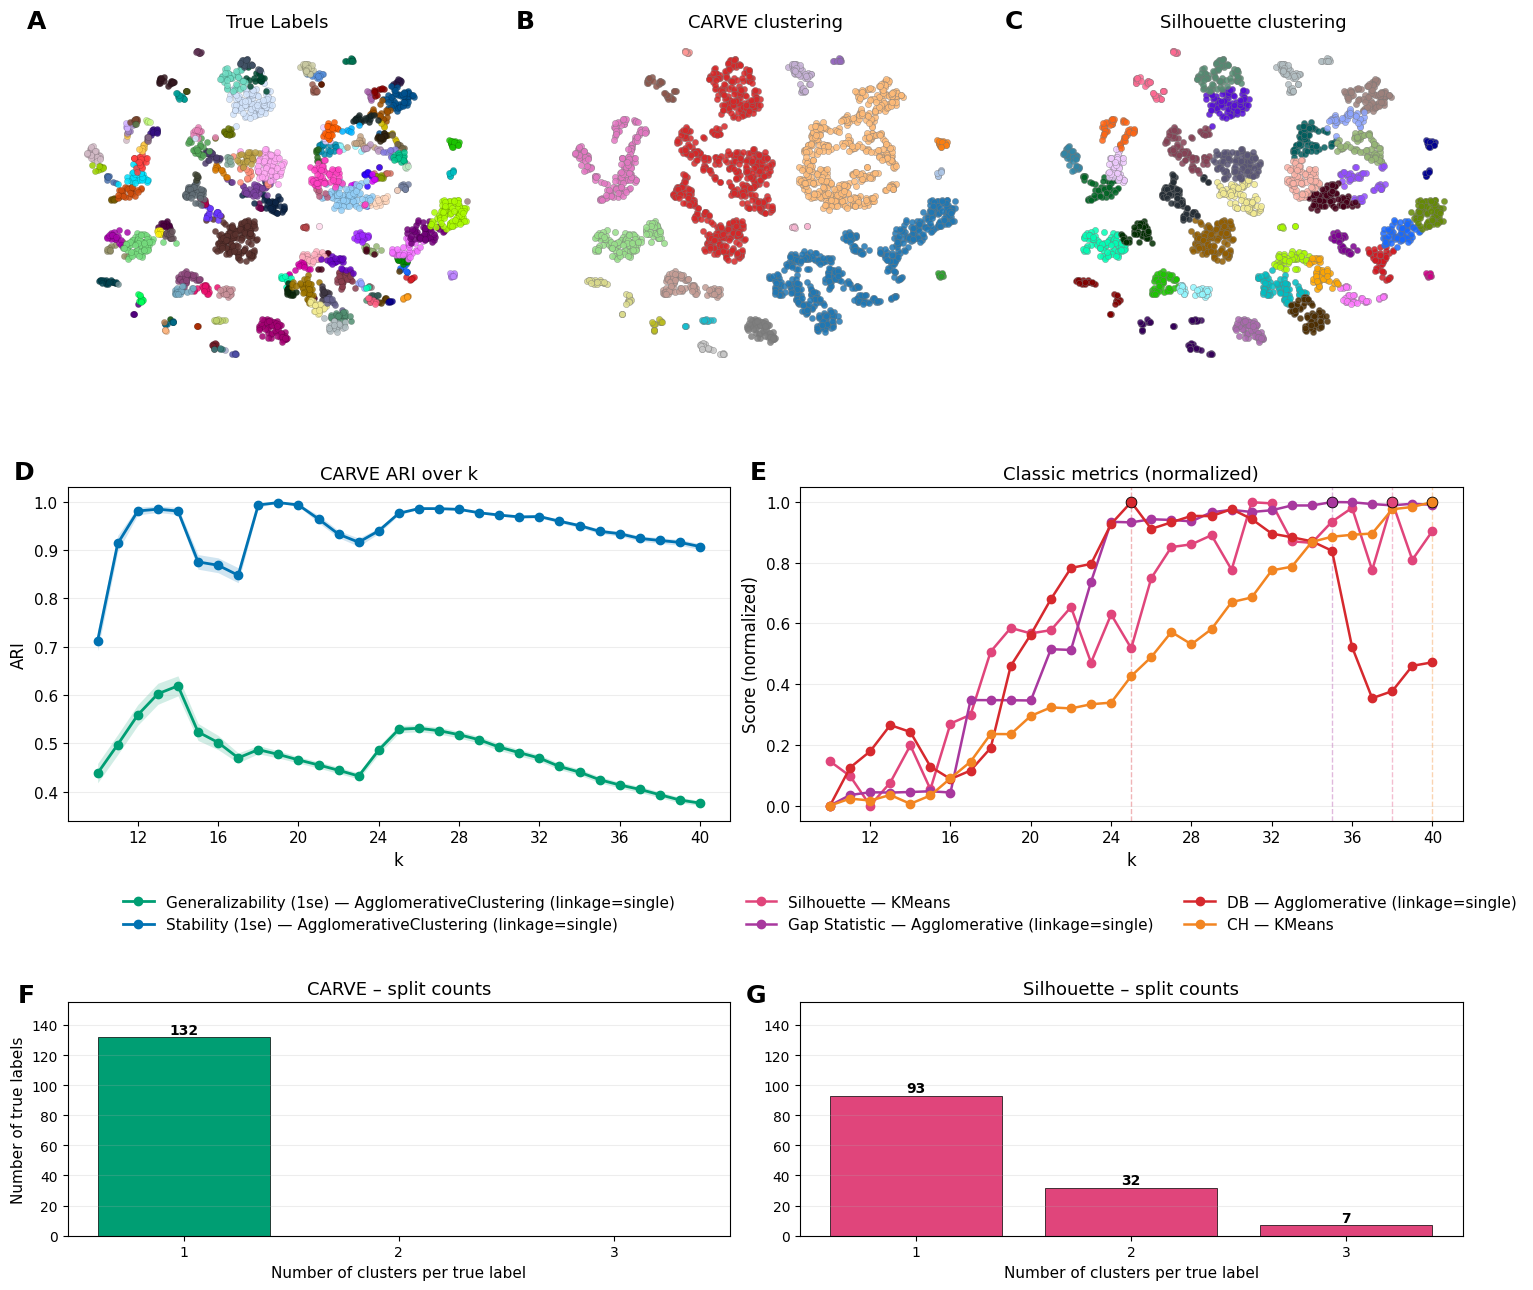

In [28]:
from benchmarking_code.case_study_plotting import plot_composite_figure_with_splits

fig = plot_composite_figure_with_splits(
    X,
    y,
    carve,
    curves_df,
    best_df,
    silhouette_labels,
    measure="s",
    rule="1se",
    carve_measures=[("generalizability", "1se"), ("stability", "1se")],
    normalize_baseline=True,
    true_label_legend_title="Cluster ID",
    carve_title="CARVE clustering",
    baseline_title="Silhouette clustering",
    carve_line_title="CARVE ARI over k",
    baseline_line_title="Classic metrics (normalized)",
    split_title_a="CARVE – split counts",
    split_title_b="Silhouette – split counts",
    figsize=(18, 16),
    scatter_s=20,
    annotate_carve=False,
    # save_path="../../vis/case_studies/tasic_composite.pdf",
)

In [ ]:
# Agglomerative k=4 (Ward) –– as suggested by silhouette
silhouette_labels = KMeans(n_clusters=33, random_state=RANDOM_SEED).fit_predict(X)

# Spectral, k=7 –– as suggested by CARVE generalizability
# carve_labels = carve.get_labels(k=24, measure="stability", rule="quantile")
carve_labels = AgglomerativeClustering(n_clusters=24, linkage="single").fit_predict(X)

fig = alluvial_compare(
    y_true=y,
    left_labels=carve_labels,
    right_labels=silhouette_labels,
    left_title="CARVE",
    right_title="Silhouette",
    true_title="True Labels",
    palette_name="tab10",
    link_alpha=0.35,
)

fig.show()

In [ ]:
plot_label_split_counts(
    y_sub.to_numpy(),
    carve_labels,
    silhouette_labels,
    title_a="CARVE – Agglomerative (single linkage)",
    title_b="Silhouette – KMeans",
)

In [ ]:
(summ_agg, splits_agg, dist_agg, top_agg), (summ_km, splits_km, dist_km, top_km) = (
    fragmentation_report(
        y_sub.to_numpy(),
        carve_labels,
        silhouette_labels,
        name_a="CARVE-selected agglomerative",
        name_b="silhouette-selected kmeans",
    )
)

In [ ]:
res_a, res_b = merging_report(
    y_true=y,
    labels_a=carve_labels,
    labels_b=silhouette_labels,
    name_a="CARVE",
    name_b="Silhouette",
)

plot_label_merge_counts(
    y, carve_labels, silhouette_labels, title_a="CARVE", title_b="Silhouette"
)

In [ ]:
plot_dim_red(X=X, y=carve_labels, show_legend=False)

In [ ]:
plot_dim_red(X=X, y=silhouette_labels, show_legend=False)

---

## 6) Motivation Plots:

In [ ]:
labels_4 = KMeans(n_clusters=4, random_state=RANDOM_SEED).fit_predict(X_raw)
labels_15 = KMeans(n_clusters=15, random_state=RANDOM_SEED).fit_predict(X_raw)
labels_30 = KMeans(n_clusters=30, random_state=RANDOM_SEED).fit_predict(X_raw)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_dim_red(
    X=X_raw,
    y=labels_4,
    legend_title="Cluster",
    ax=axes[0, 0],
    show=False,
    show_legend=False,
    title="PCA, k=4",
)
plot_dim_red(
    X=X_raw,
    y=labels_15,
    legend_title="Cluster",
    ax=axes[0, 1],
    show=False,
    show_legend=False,
    title="PCA, k=15",
)
plot_dim_red(
    X=X_raw,
    y=labels_30,
    legend_title="Cluster",
    ax=axes[0, 2],
    show=False,
    show_legend=False,
    title="PCA, k=30",
)

plot_dim_red(
    X=X_raw,
    y=labels_4,
    method="tsne",
    legend_title="Cluster",
    ax=axes[1, 0],
    show=False,
    show_legend=False,
    title="t-SNE, k=4",
)
plot_dim_red(
    X=X_raw,
    y=labels_15,
    method="tsne",
    legend_title="Cluster",
    ax=axes[1, 1],
    show=False,
    show_legend=False,
    title="t-SNE, k=15",
)
plot_dim_red(
    X=X_raw,
    y=labels_30,
    method="tsne",
    legend_title="Cluster",
    ax=axes[1, 2],
    show=False,
    show_legend=False,
    title="t-SNE, k=30",
)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=5, alpha=0.6, color="gray")
plt.xticks([])
plt.yticks([])
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Subsample X at 20% three times and plot (color by y)
n = X.shape[0]
m = int(0.10 * n)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes, start=1):
    rng = np.random.RandomState(RANDOM_SEED + i)
    idx_sample = rng.choice(n, size=m, replace=False)
    X_sample = X[idx_sample]
    y_sample = y.iloc[idx_sample]

    ax.scatter(X_sample[:, 0], X_sample[:, 1], s=5, alpha=0.6, c=y_sample, cmap="tab20")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
plot_dim_red(
    X=X,
    y=silhouette_labels,
    legend_title="Cluster",
    show_legend=False,
    title="t-SNE, k=31 (as determined by Silhouette)",
)
plot_dim_red(
    X=X,
    y=carve_labels,
    legend_title="Cluster",
    show_legend=False,
    title="t-SNE, k=27 (as determined by CARVE)",
)

---